# Import libraries

In [1]:
import cv2
import numpy as np
from utils import displayRectangle, show_roi_instructions

# Initialize video

In [3]:
path_to_video = '../../video/rijeka_tunell_car.mp4'
video = cv2.VideoCapture(path_to_video)
# video.set(cv2.CAP_PROP_POS_FRAMES, 15) # Skip first 15 frames to avoid the intro

# Detect ROI

Bbox selected: (221, 639, 104, 74)


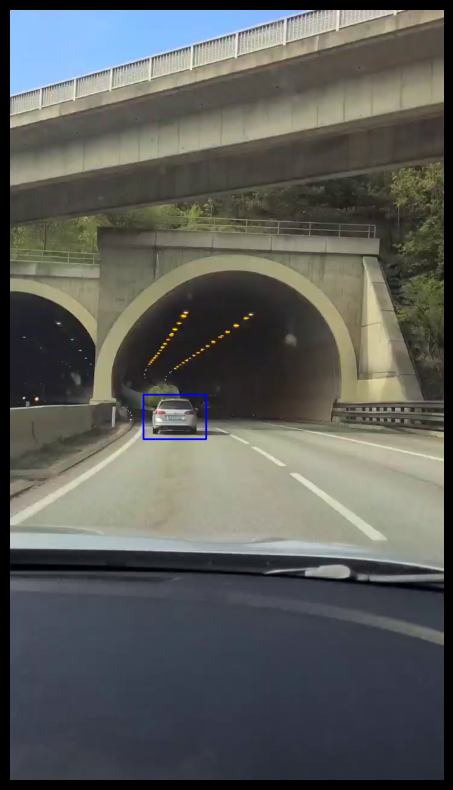

In [4]:
ok, frame = video.read()
if not ok:
    raise RuntimeError("Failed to read first frame")

show_roi_instructions(frame)

# Drag a rectangle with the mouse, press ENTER/SPACE to confirm, or ESC to cancel
object_template = cv2.selectROI("Select ROI", frame, showCrosshair=True, fromCenter=False)
cv2.destroyWindow("Select ROI")

# bbox is (x, y, w, h)
if object_template == (0, 0, 0, 0):
    raise RuntimeError("ROI selection canceled")


# video.release()
cv2.destroyAllWindows()

print(f'Bbox selected: {object_template}')
displayRectangle(frame, object_template)

In [5]:
x1, y1, w, h = map(int, object_template)
width, height = w, h

x2 = x1 + w
y2 = y1 + h

# Limit the search to a certain vicinity (since the cars can only move that fast)
search = 50

# Read the first frame used for template (already in `frame` after ROI selection)
# Build template as an image patch (grayscale, float32 in [0,1])
frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
template = frame_gray[y1:y1 + height, x1:x1 + width].astype(np.float32) / 255.0

# Initialize tracker

In [6]:
win = "Tracking"

# Create a resizable window (lets you control window size)
cv2.namedWindow(win, cv2.WINDOW_NORMAL)

while True:
    ok, frame = video.read()
    if not ok:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    # Clamp search window bounds to image
    H, W = frame_gray.shape[:2]
    sx1 = max(0, x1 - search)
    sy1 = max(0, y1 - search)
    sx2 = min(W, x1 + width + search)
    sy2 = min(H, y1 + height + search)

    search_window = frame_gray[sy1:sy2, sx1:sx2]

    # If search window is too small (near borders), skip update
    if search_window.shape[0] < height or search_window.shape[1] < width:
        cv2.rectangle(frame, (x1, y1), (x1 + width, y1 + height), (0, 255, 0), 3)
        cv2.imshow("Tracking", frame)
        if (cv2.waitKey(1) & 0xFF) == 27:
            break
        continue

    best_r, best_c = 0, 0
    best_loss = np.inf

    # SAD search
    for r in range(0, search_window.shape[0] - height + 1):
        for c in range(0, search_window.shape[1] - width + 1):
            candidate = search_window[r:r + height, c:c + width]
            loss = np.sum(np.abs(template - candidate))
            if loss < best_loss:
                best_loss = loss
                best_r, best_c = r, c

    # Update bbox in full-frame coordinates
    x1 = sx1 + best_c
    y1 = sy1 + best_r

    # Draw on the original uint8 frame (no division/scaling here)
    cv2.rectangle(frame, (x1, y1), (x1 + width, y1 + height), (0, 255, 0), 3)

    h, w = frame.shape[:2]
    # Make the window match the video/frame size
    cv2.resizeWindow(win, w, h)
    cv2.imshow("Tracking", frame)

    if (cv2.waitKey(30) & 0xFF) == 27:
        break

video.release()
cv2.destroyAllWindows()